# Imputación de valores faltantes y balanceo de clases
### *Healthcare Dataset — Stroke Prediction* (5 110 pacientes)

El dataset tiene los dos problemas clásicos de la limpieza de datos, y además **acoplados entre sí**:

1. **Valores faltantes** — `bmi` (201 nulos) y `smoking_status` (1 544 registros codificados como `"Unknown"`,
   que son nulos disfrazados de categoría).
2. **Desbalanceo severo de clases** — sólo el 4,87 % de los pacientes sufrió un ictus (249 de 5 110),
   una razón de aproximadamente **1:20**.

El acoplamiento es lo interesante: los datos no faltan al azar, faltan **justo donde están los casos positivos**.
Eliminar las filas incompletas —la salida fácil— destruiría una parte importante de la clase minoritaria,
agravando el desbalanceo que luego tendríamos que corregir.

**Plan de trabajo**

| Sección | Contenido |
|---|---|
| 1 | Exploración y diagnóstico del desbalanceo |
| 2 | Diagnóstico de los valores faltantes y de su mecanismo (MCAR / MAR / MNAR) |
| 3 | Partición train/test **antes** de imputar (evitar fuga de información) |
| 4 | Imputación: comparación medida de media, mediana, KNN y MICE |
| 5 | Balanceo: sobremuestreo, submuestreo, métodos híbridos y ponderación de clases |
| 6 | ¿Balancear o mover el umbral de decisión? |
| 7 | Conclusiones |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

RANDOM_STATE = 42

## 1. Carga y exploración inicial

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# 'id' es un identificador de paciente: no aporta información predictiva
df = df.drop(columns="id")

print("Dimensiones:", df.shape)
print("Duplicados :", df.duplicated().sum())
df.head()

Dimensiones: (5110, 11)
Duplicados : 0


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [4]:
df.describe().round(2)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,43.23,0.1,0.05,106.15,28.89,0.05
std,22.61,0.3,0.23,45.28,7.85,0.22
min,0.08,0.0,0.00,55.12,10.30,0.00
25%,25.00,0.0,0.00,77.24,23.50,0.00
50%,45.00,0.0,0.00,91.88,28.10,0.00
75%,61.00,0.0,0.00,114.09,33.10,0.00
max,82.00,1.0,1.00,271.74,97.60,1.00


In [5]:
# Valores únicos de las variables categóricas
for c in df.select_dtypes("object"):
    print(f"{c:18s} -> {list(df[c].unique())}")

gender             -> ['Male', 'Female', 'Other']
ever_married       -> ['Yes', 'No']
work_type          -> ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Residence_type     -> ['Urban', 'Rural']
smoking_status     -> ['formerly smoked', 'never smoked', 'smokes', 'Unknown']


Dos cosas saltan a la vista:

- `bmi` tiene 4 909 valores no nulos de 5 110 → **201 faltantes**.
- `smoking_status` incluye la categoría `"Unknown"`. No es una categoría real: es un **valor faltante
  disfrazado**. Lo trataremos como tal en la sección 2.

### 1.1 El desbalanceo

In [6]:
conteo = df["stroke"].value_counts().sort_index()
prevalencia = df["stroke"].mean()

resumen = pd.DataFrame({
    "pacientes": conteo,
    "porcentaje": (conteo / len(df) * 100).round(2),
}, index=pd.Index([0, 1], name="stroke"))
resumen.index = ["0 — sin ictus (mayoritaria)", "1 — con ictus (minoritaria)"]

print(resumen.to_string())
print(f"\nPrevalencia de la clase positiva : {prevalencia:.4f}  ({prevalencia*100:.2f} %)")
print(f"Razón de desbalanceo             : 1 : {conteo[0] / conteo[1]:.1f}")

                             pacientes  porcentaje
0 — sin ictus (mayoritaria)       4861       95.13
1 — con ictus (minoritaria)        249        4.87

Prevalencia de la clase positiva : 0.0487  (4.87 %)
Razón de desbalanceo             : 1 : 19.5


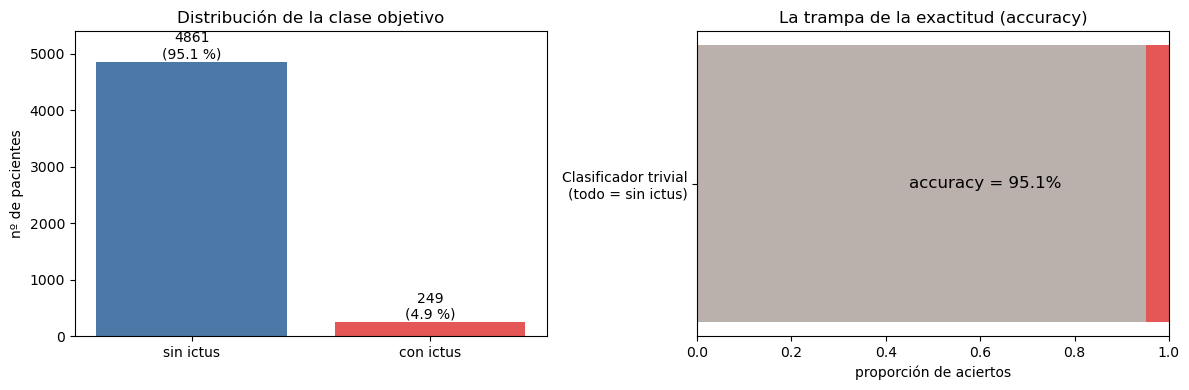

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["sin ictus", "con ictus"], conteo.values, color=["#4C78A8", "#E45756"])
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 60, f"{v}\n({v/len(df)*100:.1f} %)", ha="center", fontsize=10)
axes[0].set(ylabel="nº de pacientes", title="Distribución de la clase objetivo", ylim=(0, 5400))

# Un clasificador trivial "nadie tiene ictus" ya acierta el 95,1 %
axes[1].barh(["Clasificador trivial\n(todo = sin ictus)"], [1 - prevalencia], color="#BAB0AC")
axes[1].barh(["Clasificador trivial\n(todo = sin ictus)"], [prevalencia],
             left=[1 - prevalencia], color="#E45756")
axes[1].text(0.45, 0, f"accuracy = {1-prevalencia:.1%}", va="center", fontsize=12, color="black")
axes[1].set(xlim=(0, 1), title="La trampa de la exactitud (accuracy)")
axes[1].set_xlabel("proporción de aciertos")

plt.tight_layout()
plt.show()

Con una prevalencia del 4,87 %, un modelo que **nunca** prediga ictus obtiene un **95,1 % de exactitud**
y es completamente inútil desde el punto de vista clínico: no detecta a ni un solo paciente en riesgo.
Por eso, a partir de aquí la exactitud queda relegada y usaremos **recall (sensibilidad), precisión, F1,
ROC-AUC y PR-AUC**.

## 2. Diagnóstico de los valores faltantes

### 2.1 Recuperar los nulos ocultos

In [8]:
# "Unknown" en smoking_status es un nulo codificado como texto: lo convertimos a NaN
print("Antes :", df["smoking_status"].value_counts().to_dict())

df["smoking_status"] = df["smoking_status"].replace("Unknown", np.nan)

print("Después:", df["smoking_status"].value_counts(dropna=False).to_dict())

Antes : {'never smoked': 1892, 'Unknown': 1544, 'formerly smoked': 885, 'smokes': 789}
Después: {'never smoked': 1892, nan: 1544, 'formerly smoked': 885, 'smokes': 789}


In [9]:
faltantes = pd.DataFrame({
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "tipo": df.dtypes.astype(str),
})
faltantes[faltantes["nulos"] > 0]

,nulos,% nulos,tipo
bmi,201,3.93,float64
smoking_status,1544,30.22,object


In [10]:
# ¿Se solapan los dos patrones de ausencia?
patron = (df[["bmi", "smoking_status"]].isna()
          .value_counts()
          .rename_axis(["bmi nulo", "smoking nulo"])
          .rename("pacientes")
          .reset_index())
patron["%"] = (patron["pacientes"] / len(df) * 100).round(2)
print(patron.to_string(index=False))
print(f"\nFilas con al menos un nulo: {df.isna().any(axis=1).sum()} "
      f"({df.isna().any(axis=1).mean()*100:.1f} % del dataset)")

 bmi nulo  smoking nulo  pacientes     %
    False         False       3426 67.05
    False          True       1483 29.02
     True         False        140  2.74
     True          True         61  1.19

Filas con al menos un nulo: 1684 (33.0 % del dataset)


### 2.2 ¿Por qué faltan? El mecanismo de ausencia

Antes de imputar hay que preguntarse **por qué** falta el dato. Se distinguen tres mecanismos:

- **MCAR** (*Missing Completely At Random*) — la ausencia es independiente de todo. Imputar es seguro
  y eliminar filas sólo cuesta tamaño muestral.
- **MAR** (*Missing At Random*) — la ausencia depende de **otras variables observadas**. Imputar con
  un modelo multivariante (KNN, MICE) es lo correcto; eliminar filas **sesga** el dataset.
- **MNAR** (*Missing Not At Random*) — la ausencia depende del propio valor no observado. Ni imputar
  ni eliminar lo resuelve del todo: hay que **registrar la ausencia como información**.

Comprobémoslo empíricamente: comparamos los pacientes con `bmi` nulo frente a los que lo tienen.

In [11]:
df["_bmi_nulo"] = df["bmi"].isna()

comparacion = df.groupby("_bmi_nulo").agg(
    pacientes=("stroke", "size"),
    edad_media=("age", "mean"),
    glucosa_media=("avg_glucose_level", "mean"),
    hipertension=("hypertension", "mean"),
    cardiopatia=("heart_disease", "mean"),
    tasa_ictus=("stroke", "mean"),
).round(3)
comparacion.index = ["bmi observado", "bmi FALTANTE"]
comparacion

,pacientes,edad_media,glucosa_media,hipertension,cardiopatia,tasa_ictus
bmi observado,4909,42.865,105.305,0.092,0.050,0.043
bmi FALTANTE,201,52.049,126.725,0.234,0.164,0.199


In [12]:
tasa_obs = df.loc[~df["_bmi_nulo"], "stroke"].mean()
tasa_nul = df.loc[df["_bmi_nulo"], "stroke"].mean()

print(f"Tasa de ictus con bmi observado : {tasa_obs:.2%}")
print(f"Tasa de ictus con bmi FALTANTE  : {tasa_nul:.2%}")
print(f"Riesgo relativo                 : x{tasa_nul / tasa_obs:.1f}")

# Test chi-cuadrado de independencia entre 'bmi está ausente' y 'stroke'
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df["_bmi_nulo"], df["stroke"])
chi2, p, gl, _ = chi2_contingency(tabla)
print(f"\nChi-cuadrado de independencia: chi2 = {chi2:.1f}, gl = {gl}, p = {p:.3e}")
print("=> La ausencia de 'bmi' NO es independiente del ictus: el mecanismo no es MCAR.")

Tasa de ictus con bmi observado : 4.26%
Tasa de ictus con bmi FALTANTE  : 19.90%
Riesgo relativo                 : x4.7



Chi-cuadrado de independencia: chi2 = 98.6, gl = 1, p = 3.108e-23
=> La ausencia de 'bmi' NO es independiente del ictus: el mecanismo no es MCAR.


El resultado es contundente: **un paciente sin `bmi` registrado tiene casi 5 veces más probabilidad
de haber sufrido un ictus** (19,9 % frente a 4,3 %). También es en promedio 9 años mayor y tiene la
glucosa más alta. Tiene sentido clínico: a un paciente que ingresa por un ictus grave no siempre se
le puede pesar y medir.

Esto tiene dos consecuencias prácticas:

In [13]:
sin_nulos = df.dropna(subset=["bmi"])

impacto = pd.DataFrame({
    "dataset completo": [len(df), int(df["stroke"].sum()), df["stroke"].mean()],
    "eliminando filas con bmi nulo": [len(sin_nulos), int(sin_nulos["stroke"].sum()), sin_nulos["stroke"].mean()],
}, index=["filas", "casos positivos (ictus)", "prevalencia"]).round(4)

perdidos = int(df["stroke"].sum() - sin_nulos["stroke"].sum())
impacto.loc["filas eliminadas"] = [0, len(df) - len(sin_nulos)]
impacto.loc["positivos perdidos"] = [0, perdidos]

print(impacto.to_string())
print(f"\nEliminar esas 201 filas (3,9 % del dataset) borra {perdidos} de los {int(df['stroke'].sum())} "
      f"casos de ictus: el {perdidos/df['stroke'].sum():.1%} de la clase minoritaria.")
print("La prevalencia caería del 4,87 % al 4,26 %: el desbalanceo EMPEORA.")

                         dataset completo  eliminando filas con bmi nulo
filas                           5110.0000                      4909.0000
casos positivos (ictus)          249.0000                       209.0000
prevalencia                        0.0487                         0.0426
filas eliminadas                   0.0000                       201.0000
positivos perdidos                 0.0000                        40.0000

Eliminar esas 201 filas (3,9 % del dataset) borra 40 de los 249 casos de ictus: el 16.1% de la clase minoritaria.
La prevalencia caería del 4,87 % al 4,26 %: el desbalanceo EMPEORA.


**Conclusión 1 —** eliminar filas está descartado: perderíamos el 16 % de la clase que precisamente
queremos aprender a detectar.

**Conclusión 2 —** como la ausencia es informativa (mecanismo MAR/MNAR), además de imputar el valor
crearemos **variables indicadoras de ausencia** (`bmi_missing`, `smoking_missing`). Así el modelo
conserva la señal "a este paciente no se le midió el IMC", que resultó ser un predictor por sí misma.

In [14]:
df = df.drop(columns="_bmi_nulo")

VAR_NUM = ["age", "avg_glucose_level", "bmi"]
VAR_CAT = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
VAR_BIN = ["hypertension", "heart_disease"]

X = df.drop(columns="stroke")
y = df["stroke"].to_numpy()
print("X:", X.shape, "| y:", y.shape)

X: (5110, 10) | y: (5110,)


## 3. Partición train/test — antes de imputar

Un error habitual es imputar sobre el dataset completo y particionar después. Eso es **fuga de
información** (*data leakage*): la media, los vecinos o el modelo MICE usados para rellenar el train
habrían visto los datos de test, y la evaluación quedaría inflada.

El orden correcto es: **particionar → ajustar el imputador sólo con el train → aplicarlo a ambos**.
Lo mismo vale para el balanceo: **el conjunto de test nunca se remuestrea**, debe conservar la
prevalencia real del 4,87 % para que las métricas signifiquen algo.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,            # conserva la prevalencia en ambos conjuntos
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape[0]} pacientes | positivos: {y_train.sum():3d} ({y_train.mean():.2%})")
print(f"Test : {X_test.shape[0]} pacientes | positivos: {y_test.sum():3d} ({y_test.mean():.2%})")

Train: 4088 pacientes | positivos: 199 (4.87%)
Test : 1022 pacientes | positivos:  50 (4.89%)


In [16]:
# Indicadores de ausencia: se calculan ANTES de imputar, porque después ya no hay nulos que marcar
def anadir_indicadores(d):
    d = d.copy()
    d["bmi_missing"] = d["bmi"].isna().astype(int)
    d["smoking_missing"] = d["smoking_status"].isna().astype(int)
    return d

X_train = anadir_indicadores(X_train)
X_test = anadir_indicadores(X_test)

VAR_FLAG = ["bmi_missing", "smoking_missing"]

print("Nulos en train:", X_train.isna().sum().sum(), "| Nulos en test:", X_test.isna().sum().sum())
X_train.head(3)

Nulos en train: 1417 | Nulos en test: 328


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,bmi_missing,smoking_missing
845,Female,48.0,0,0,Yes,Private,Urban,69.21,33.1,never smoked,0,0
3744,Male,15.0,0,0,No,Private,Rural,122.25,21.0,never smoked,0,0
4183,Female,67.0,0,0,Yes,Self-employed,Rural,110.42,24.9,never smoked,0,0


## 4. Imputación de los valores faltantes

### 4.1 ¿Qué imputador elegir? Midámoslo

En lugar de escoger por costumbre, medimos. El procedimiento es un **experimento de ocultación**:
tomamos los valores de `bmi` que **sí** conocemos en el train, escondemos un 20 % al azar, imputamos
con cada método y comparamos contra el valor verdadero (RMSE y MAE).

Comparamos cinco estrategias:

| Método | Tipo | Idea |
|---|---|---|
| Media | univariante | todos los nulos reciben el mismo valor |
| Mediana | univariante | igual, pero robusta a valores extremos |
| KNN (k=5, k=10) | multivariante | promedio del IMC de los pacientes más parecidos |
| MICE (`IterativeImputer`) | multivariante | regresión iterativa de `bmi` sobre el resto de variables |

In [17]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (activa IterativeImputer)
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error


# Oculta una fracción de los valores observados y mide el error de reconstrucción
def comparar_imputadores(datos, columna="bmi", frac_oculta=0.20, seed=RANDOM_STATE):
    observados = datos.index[datos[columna].notna()]
    rng = np.random.default_rng(seed)
    ocultos = rng.choice(observados, size=int(frac_oculta * len(observados)), replace=False)
    verdad = datos.loc[ocultos, columna].to_numpy()

    base = datos.copy()
    base.loc[ocultos, columna] = np.nan

    # Los imputadores multivariantes necesitan matriz numérica: codificamos las categóricas
    M = base.copy()
    M[VAR_CAT] = OrdinalEncoder(encoded_missing_value=np.nan).fit_transform(base[VAR_CAT])

    metodos = {
        "Media":            SimpleImputer(strategy="mean"),
        "Mediana":          SimpleImputer(strategy="median"),
        "KNN (k=5)":        KNNImputer(n_neighbors=5),
        "KNN (k=10)":       KNNImputer(n_neighbors=10),
        "MICE (Iterative)": IterativeImputer(random_state=RANDOM_STATE, max_iter=20),
    }

    filas = {}
    for nombre, imputador in metodos.items():
        esc = StandardScaler()                              # KNN y MICE dependen de la escala
        Ms = pd.DataFrame(esc.fit_transform(M), columns=M.columns, index=M.index)
        rellenado = pd.DataFrame(imputador.fit_transform(Ms), columns=M.columns, index=M.index)
        rellenado = pd.DataFrame(esc.inverse_transform(rellenado),
                                 columns=M.columns, index=M.index)
        pred = rellenado.loc[ocultos, columna].to_numpy()
        filas[nombre] = {
            "RMSE": np.sqrt(mean_squared_error(verdad, pred)),
            "MAE": np.abs(verdad - pred).mean(),
            "desv. típica imputada": pred.std(),
        }

    tabla = pd.DataFrame(filas).T.round(3)
    tabla["mejora RMSE vs media"] = ((1 - tabla["RMSE"] / tabla.loc["Media", "RMSE"]) * 100).round(1)
    return tabla, verdad.std()


ranking, std_real = comparar_imputadores(X_train)
print(f"Desviación típica real de los valores ocultados: {std_real:.3f}\n")
ranking

Desviación típica real de los valores ocultados: 7.616



,RMSE,MAE,desv. típica imputada,mejora RMSE vs media
Media,7.618,5.809,0.000,0.0
Mediana,7.648,5.748,0.000,-0.4
KNN (k=5),7.150,5.276,4.874,6.1
KNN (k=10),6.855,5.102,4.507,10.0
MICE (Iterative),6.736,5.087,3.410,11.6


Dos lecturas de la tabla:

- **MICE reduce el RMSE un 11,6 %** y KNN(k=10) un 10,0 % frente a la media. La mejora viene de usar
  la información de `age`, `avg_glucose_level`, `ever_married`, etc., correlacionadas con el IMC.
  La mediana es incluso ligeramente **peor** que la media en RMSE (−0,4 %).
- La columna *desv. típica imputada* destapa el problema oculto de la media/mediana: imputan siempre
  la misma constante, con **desviación típica exactamente 0**. Eso **encoge artificialmente la varianza**
  de la variable. Conviene ser honestos: ningún método la recupera del todo (los valores reales
  ocultados tenían σ = 7,62, y MICE produce σ = 3,41), porque una imputación puntual predice la
  *media condicional*, no una muestra de la distribución. Aun así, 3,41 es mucho mejor que 0.

Elegimos **MICE (`IterativeImputer`)** para las variables numéricas y la **moda** para
`smoking_status` (categórica), reteniendo siempre los indicadores de ausencia.

In [18]:
from sklearn.compose import ColumnTransformer

imputador = ColumnTransformer(
    transformers=[
        ("num", IterativeImputer(random_state=RANDOM_STATE, max_iter=20), VAR_NUM),
        ("cat", SimpleImputer(strategy="most_frequent"), VAR_CAT),
        ("resto", "passthrough", VAR_BIN + VAR_FLAG),
    ],
    verbose_feature_names_out=False,
)

COLUMNAS = VAR_NUM + VAR_CAT + VAR_BIN + VAR_FLAG

# fit SÓLO con el train; el test únicamente se transforma
X_train_imp = pd.DataFrame(imputador.fit_transform(X_train), columns=COLUMNAS, index=X_train.index)
X_test_imp = pd.DataFrame(imputador.transform(X_test), columns=COLUMNAS, index=X_test.index)

for d in (X_train_imp, X_test_imp):
    d[VAR_NUM] = d[VAR_NUM].astype(float)
    d[VAR_BIN + VAR_FLAG] = d[VAR_BIN + VAR_FLAG].astype(int)

print("Nulos restantes -> train:", X_train_imp.isna().sum().sum(),
      "| test:", X_test_imp.isna().sum().sum())
X_train_imp.head()

Nulos restantes -> train: 0 | test: 0


,age,avg_glucose_level,bmi,gender,ever_married,work_type,Residence_type,smoking_status,hypertension,heart_disease,bmi_missing,smoking_missing
845,48.0,69.21,33.1,Female,Yes,Private,Urban,never smoked,0,0,0,0
3744,15.0,122.25,21.0,Male,No,Private,Rural,never smoked,0,0,0,0
4183,67.0,110.42,24.9,Female,Yes,Self-employed,Rural,never smoked,0,0,0,0
3409,44.0,65.41,24.8,Male,Yes,Private,Urban,smokes,0,0,0,0
284,14.0,82.34,31.6,Male,No,Govt_job,Urban,never smoked,0,0,0,1


### 4.2 ¿Deformó la imputación los datos?

In [19]:
mascara = X_train["bmi"].isna().to_numpy()

efecto = pd.DataFrame({
    "bmi original (sólo observados)": X_train["bmi"].describe(),
    "bmi tras imputar (todos)": X_train_imp["bmi"].describe(),
    f"sólo los {mascara.sum()} imputados": X_train_imp.loc[mascara, "bmi"].describe(),
}).round(2)
efecto

,bmi original (sólo observados),bmi tras imputar (todos),sólo los 170 imputados
count,3918.00,4088.00,170.00
mean,28.92,28.99,30.44
std,7.93,7.79,2.87
min,10.30,10.30,23.68
25%,23.60,23.80,28.22
50%,28.00,28.20,31.28
75%,33.10,33.00,32.51
max,97.60,97.60,35.32


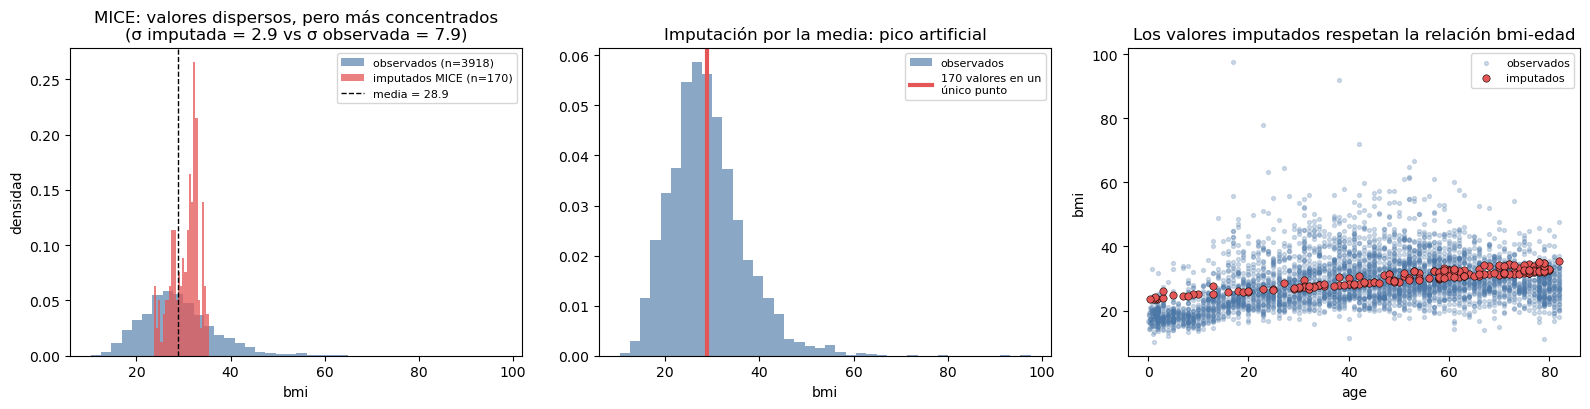

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 1) Distribución antes / después
axes[0].hist(X_train["bmi"].dropna(), bins=40, alpha=0.65, color="#4C78A8",
             label=f"observados (n={(~mascara).sum()})", density=True)
axes[0].hist(X_train_imp.loc[mascara, "bmi"], bins=25, alpha=0.75, color="#E45756",
             label=f"imputados MICE (n={mascara.sum()})", density=True)
axes[0].axvline(X_train["bmi"].mean(), color="black", ls="--", lw=1,
                label=f"media = {X_train['bmi'].mean():.1f}")
axes[0].set(xlabel="bmi", ylabel="densidad",
            title=f"MICE: valores dispersos, pero más concentrados\n"
                  f"(σ imputada = {X_train_imp.loc[mascara,'bmi'].std():.1f} "
                  f"vs σ observada = {X_train['bmi'].std():.1f})")
axes[0].legend(fontsize=8)

# 2) Qué habría hecho la imputación por la media
axes[1].hist(X_train["bmi"].dropna(), bins=40, alpha=0.65, color="#4C78A8",
             label="observados", density=True)
axes[1].axvline(X_train["bmi"].mean(), color="#E45756", lw=3,
                label=f"{mascara.sum()} valores en un\núnico punto")
axes[1].set(xlabel="bmi", title="Imputación por la media: pico artificial")
axes[1].legend(fontsize=8)

# 3) Relación bmi-edad: los imputados deben caer donde toca
axes[2].scatter(X_train.loc[~mascara, "age"], X_train.loc[~mascara, "bmi"],
                s=8, alpha=0.25, color="#4C78A8", label="observados")
axes[2].scatter(X_train.loc[mascara, "age"], X_train_imp.loc[mascara, "bmi"],
                s=28, color="#E45756", edgecolor="black", lw=0.4, label="imputados")
axes[2].set(xlabel="age", ylabel="bmi", title="Los valores imputados respetan la relación bmi-edad")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

La imputación por la media habría concentrado los 170 pacientes en un único punto (segundo panel): un
pico artificial que ningún dato real produce. MICE los reparte a lo largo de un rango y, sobre todo,
**los coloca donde la relación `bmi`-`age` dice que deben estar** (tercer panel): los pacientes jóvenes
reciben un IMC bajo y los mayores uno alto, cosa que la media no puede hacer.

Ahora bien, el primer panel deja ver el límite del método: los valores imputados son **más
concentrados** que los reales (σ = 2,9 frente a 7,9) y se apilan en torno a la moda. Es inevitable en
cualquier imputación puntual, que predice la *media condicional* en lugar de muestrear la
distribución. Si el objetivo fuera estimar intervalos de confianza haría falta **imputación múltiple**
(varios datasets imputados y agregación de resultados); para entrenar un clasificador, esta versión
puntual es suficiente.

**Los valores faltantes están recuperados.** Pasamos al segundo problema.

## 5. Balanceo de clases

El train tiene 3 889 negativos frente a 199 positivos. Hay tres familias de soluciones:

| Familia | Métodos | Qué hace |
|---|---|---|
| **Sobremuestreo** | `RandomOverSampler`, `SMOTE`, `ADASYN` | añade ejemplos de la clase minoritaria |
| **Submuestreo** | `RandomUnderSampler`, `TomekLinks`, `ENN` | quita ejemplos de la clase mayoritaria |
| **Híbridos / algorítmicos** | `SMOTETomek`, `SMOTEENN`, `class_weight` | combinan, o penalizan más el error en la minoritaria |

Nota: `EditedNearestNeighbours` (ENN) es exactamente la **edición de Wilson** del ejercicio anterior,
aplicada aquí como limpiador de la clase mayoritaria.

In [21]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as PipelineImb

# Codificación: escalar numéricas + one-hot para categóricas. Las binarias y los flags pasan tal cual
preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), VAR_NUM),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), VAR_CAT),
        ("resto", "passthrough", VAR_BIN + VAR_FLAG),
    ],
    verbose_feature_names_out=False,
)

X_train_cod = preprocesador.fit_transform(X_train_imp)
X_test_cod = preprocesador.transform(X_test_imp)
NOMBRES = list(preprocesador.get_feature_names_out())

print("Matriz codificada:", X_train_cod.shape, "->", len(NOMBRES), "variables")
print(NOMBRES)

Matriz codificada: (4088, 20) -> 20 variables
['age', 'avg_glucose_level', 'bmi', 'gender_Female', 'gender_Male', 'gender_Other', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'hypertension', 'heart_disease', 'bmi_missing', 'smoking_missing']


### 5.1 Qué le hace cada técnica al conjunto de entrenamiento

In [22]:
TECNICAS = {
    "RandomOverSampler":  RandomOverSampler(random_state=RANDOM_STATE),
    "SMOTE":              SMOTE(random_state=RANDOM_STATE),
    "ADASYN":             ADASYN(random_state=RANDOM_STATE),
    "RandomUnderSampler": RandomUnderSampler(random_state=RANDOM_STATE),
    "TomekLinks":         TomekLinks(),
    "ENN (Wilson)":       EditedNearestNeighbours(),
    "SMOTE + Tomek":      SMOTETomek(random_state=RANDOM_STATE),
    "SMOTE + ENN":        SMOTEENN(random_state=RANDOM_STATE),
}

filas = [{"técnica": "— sin balanceo —",
          "clase 0": int((y_train == 0).sum()), "clase 1": int((y_train == 1).sum()),
          "total": len(y_train), "% minoritaria": y_train.mean() * 100}]

remuestreos = {}
for nombre, tecnica in TECNICAS.items():
    Xr, yr = tecnica.fit_resample(X_train_cod, y_train)
    remuestreos[nombre] = (Xr, yr)
    filas.append({"técnica": nombre,
                  "clase 0": int((yr == 0).sum()), "clase 1": int((yr == 1).sum()),
                  "total": len(yr), "% minoritaria": yr.mean() * 100})

tabla_remuestreo = pd.DataFrame(filas).set_index("técnica").round(1)
tabla_remuestreo["Δ total"] = tabla_remuestreo["total"] - len(y_train)
tabla_remuestreo

,clase 0,clase 1,total,% minoritaria,Δ total
técnica,,,,,
— sin balanceo —,3889,199,4088,4.9,0
RandomOverSampler,3889,3889,7778,50.0,3690
SMOTE,3889,3889,7778,50.0,3690
ADASYN,3889,3815,7704,49.5,3616
RandomUnderSampler,199,199,398,50.0,-3690
TomekLinks,3800,199,3999,5.0,-89
ENN (Wilson),3499,199,3698,5.4,-390
SMOTE + Tomek,3881,3881,7762,50.0,3674
SMOTE + ENN,3276,3796,7072,53.7,2984


Se ven las tres estrategias con claridad:

- **Sobremuestreo** — lleva la minoritaria hasta 3 889 (duplicando o sintetizando ejemplos): el train
  casi se dobla, hasta 7 778 filas.
- **Submuestreo agresivo** (`RandomUnderSampler`) — iguala por abajo, a 199 por clase: quedan 398 filas
  y **tiramos el 90 % de los datos**.
- **Limpiadores de frontera** (`TomekLinks`, `ENN`) — no buscan igualar, sólo eliminan los negativos
  que se solapan con positivos: 89 y 390 filas respectivamente. El desbalanceo apenas se mueve
  (4,9 % → 5,0 % / 5,4 %), porque nunca tocan la clase minoritaria.

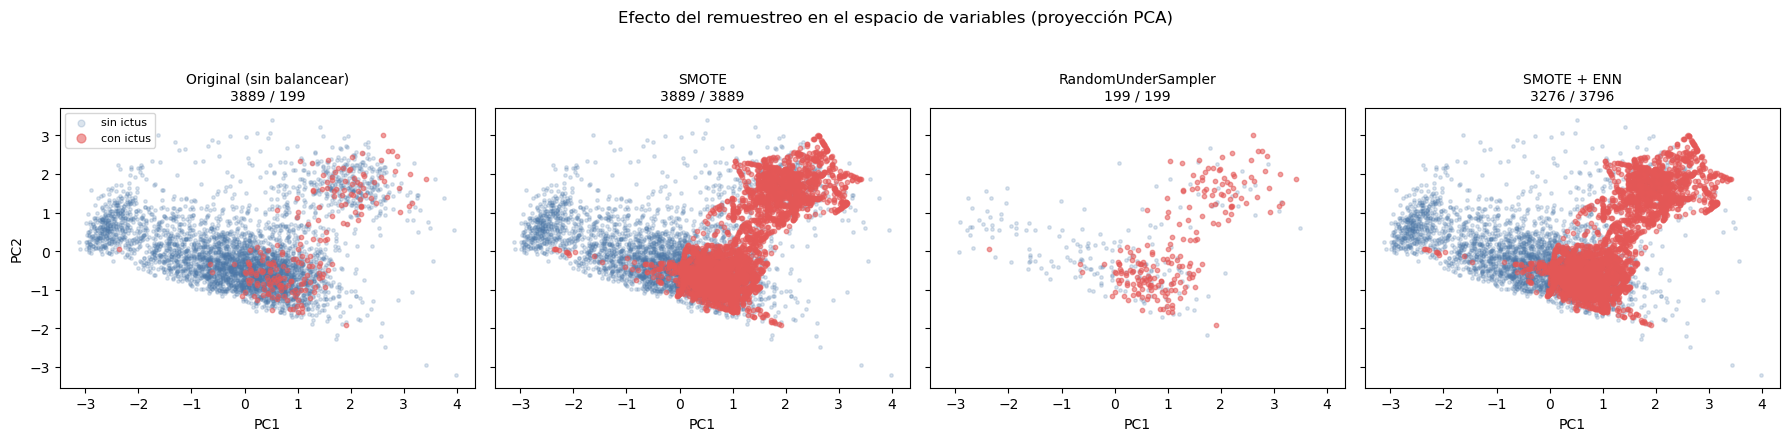

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train_cod)

paneles = [("Original (sin balancear)", X_train_cod, y_train),
           ("SMOTE", *remuestreos["SMOTE"]),
           ("RandomUnderSampler", *remuestreos["RandomUnderSampler"]),
           ("SMOTE + ENN", *remuestreos["SMOTE + ENN"])]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharex=True, sharey=True)
for ax, (titulo, Xp, yp) in zip(axes, paneles):
    P = pca.transform(Xp)
    ax.scatter(P[yp == 0, 0], P[yp == 0, 1], s=6, alpha=0.20, color="#4C78A8", label="sin ictus")
    ax.scatter(P[yp == 1, 0], P[yp == 1, 1], s=10, alpha=0.55, color="#E45756", label="con ictus")
    ax.set_title(f"{titulo}\n{(yp==0).sum()} / {(yp==1).sum()}", fontsize=10)
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8, markerscale=2)
plt.suptitle("Efecto del remuestreo en el espacio de variables (proyección PCA)", y=1.04)
plt.tight_layout()
plt.show()

### 5.2 Evaluación: ¿sirve de algo?

Entrenamos una **regresión logística** con cada estrategia y evaluamos siempre sobre el **mismo test
intacto** (1 022 pacientes, 50 positivos, prevalencia real). El remuestreo va dentro de un
`Pipeline` de `imbalanced-learn`, que aplica el sampler **sólo en el `fit`** y nunca en la predicción.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             balanced_accuracy_score, roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve)


def evaluar(sampler, nombre, clf=None):
    if clf is None:
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    pasos = [] if sampler is None else [("balanceo", sampler)]
    pasos.append(("clf", clf))
    modelo = PipelineImb(pasos).fit(X_train_cod, y_train)

    pred = modelo.predict(X_test_cod)
    proba = modelo.predict_proba(X_test_cod)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    return modelo, proba, {
        "estrategia": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "precisión": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
        "bal. acc.": balanced_accuracy_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "TP": tp, "FN": fn, "FP": fp, "TN": tn,
    }


experimentos = [(None, "— sin balanceo —", None),
                (None, "class_weight='balanced'",
                 LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]
experimentos += [(t, n, None) for n, t in TECNICAS.items()]

resultados, probas, modelos = [], {}, {}
for sampler, nombre, clf in experimentos:
    modelo, proba, fila = evaluar(sampler, nombre, clf)
    resultados.append(fila)
    probas[nombre] = proba
    modelos[nombre] = modelo

tabla = pd.DataFrame(resultados).set_index("estrategia")
tabla.round(3)

,accuracy,recall,precisión,F1,bal. acc.,ROC-AUC,PR-AUC,TP,FN,FP,TN
estrategia,,,,,,,,,,,
— sin balanceo —,0.952,0.02,1.000,0.039,0.510,0.843,0.264,1,49,0,972
class_weight='balanced',0.758,0.80,0.144,0.245,0.778,0.843,0.262,40,10,237,735
RandomOverSampler,0.763,0.80,0.147,0.248,0.781,0.844,0.255,40,10,232,740
SMOTE,0.753,0.80,0.142,0.241,0.776,0.843,0.268,40,10,242,730
ADASYN,0.747,0.78,0.136,0.231,0.762,0.843,0.272,39,11,248,724
RandomUnderSampler,0.749,0.76,0.134,0.228,0.754,0.842,0.297,38,12,245,727
TomekLinks,0.952,0.02,1.000,0.039,0.510,0.843,0.260,1,49,0,972
ENN (Wilson),0.952,0.08,0.571,0.140,0.538,0.843,0.263,4,46,3,969
SMOTE + Tomek,0.755,0.80,0.143,0.242,0.777,0.843,0.268,40,10,240,732


In [25]:
orden = tabla.sort_values("F1", ascending=False)
print("Ordenado por F1 (equilibrio entre detectar y no dar falsas alarmas):\n")
print(orden[["recall", "precisión", "F1", "bal. acc.", "PR-AUC", "TP", "FN", "FP"]].round(3).to_string())

Ordenado por F1 (equilibrio entre detectar y no dar falsas alarmas):

                         recall  precisión     F1  bal. acc.  PR-AUC  TP  FN   FP
estrategia                                                                       
RandomOverSampler          0.80      0.147  0.248      0.781   0.255  40  10  232
class_weight='balanced'    0.80      0.144  0.245      0.778   0.262  40  10  237
SMOTE + Tomek              0.80      0.143  0.242      0.777   0.268  40  10  240
SMOTE                      0.80      0.142  0.241      0.776   0.268  40  10  242
ADASYN                     0.78      0.136  0.231      0.762   0.272  39  11  248
RandomUnderSampler         0.76      0.134  0.228      0.754   0.297  38  12  245
SMOTE + ENN                0.80      0.129  0.222      0.761   0.274  40  10  270
ENN (Wilson)               0.08      0.571  0.140      0.538   0.263   4  46    3
— sin balanceo —           0.02      1.000  0.039      0.510   0.264   1  49    0
TomekLinks                 0

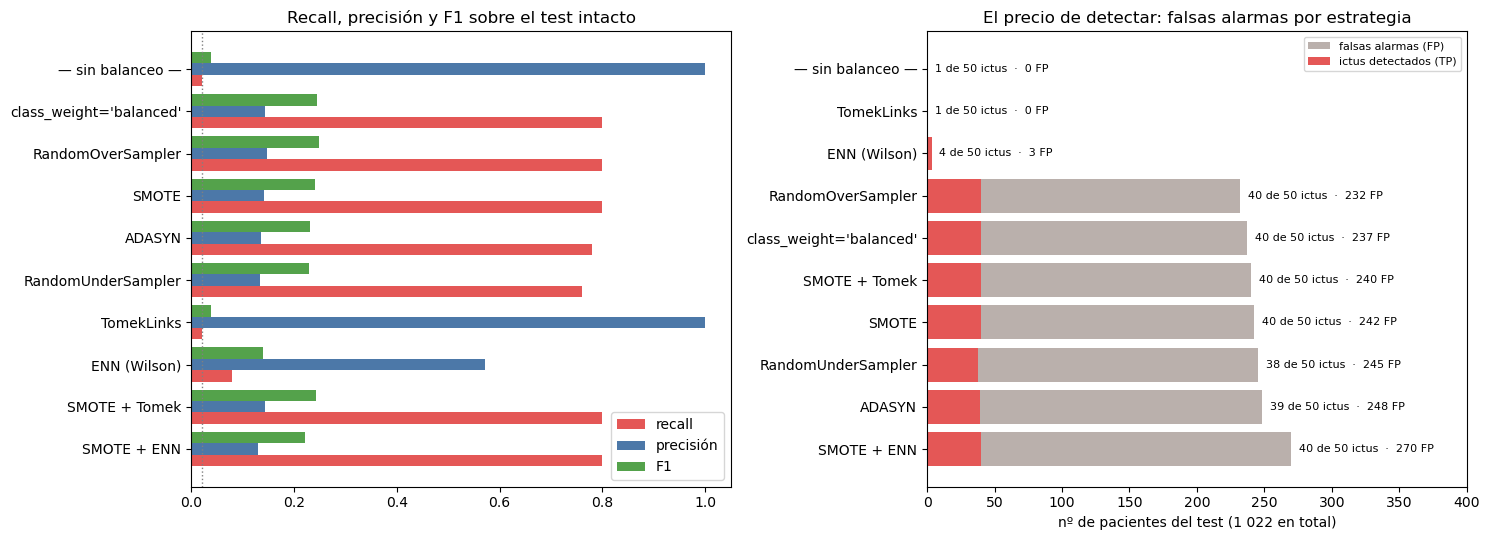

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

m = tabla[["recall", "precisión", "F1"]]
pos = np.arange(len(m))
w = 0.27
for i, (col, color) in enumerate(zip(m.columns, ["#E45756", "#4C78A8", "#54A24B"])):
    axes[0].barh(pos + (1 - i) * w, m[col], w, label=col, color=color)
axes[0].set(yticks=pos, yticklabels=m.index, xlim=(0, 1.05),
            title="Recall, precisión y F1 sobre el test intacto")
axes[0].axvline(m.loc["— sin balanceo —", "recall"], color="gray", ls=":", lw=1)
axes[0].legend(loc="lower right")
axes[0].invert_yaxis()

# El precio de detectar: cuántas falsas alarmas cuesta cada estrategia
coste = tabla.sort_values("FP")
pos2 = np.arange(len(coste))
axes[1].barh(pos2, coste["FP"], color="#BAB0AC", label="falsas alarmas (FP)")
axes[1].barh(pos2, coste["TP"], color="#E45756", label="ictus detectados (TP)")
for j, (fp, tp) in enumerate(zip(coste["FP"], coste["TP"])):
    axes[1].text(fp + 6, j, f"{tp} de {int(y_test.sum())} ictus  ·  {fp} FP",
                 va="center", fontsize=8)
axes[1].set(yticks=pos2, yticklabels=coste.index, xlim=(0, 400),
            xlabel="nº de pacientes del test (1 022 en total)",
            title="El precio de detectar: falsas alarmas por estrategia")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 5.3 Matrices de confusión: el antes y el después

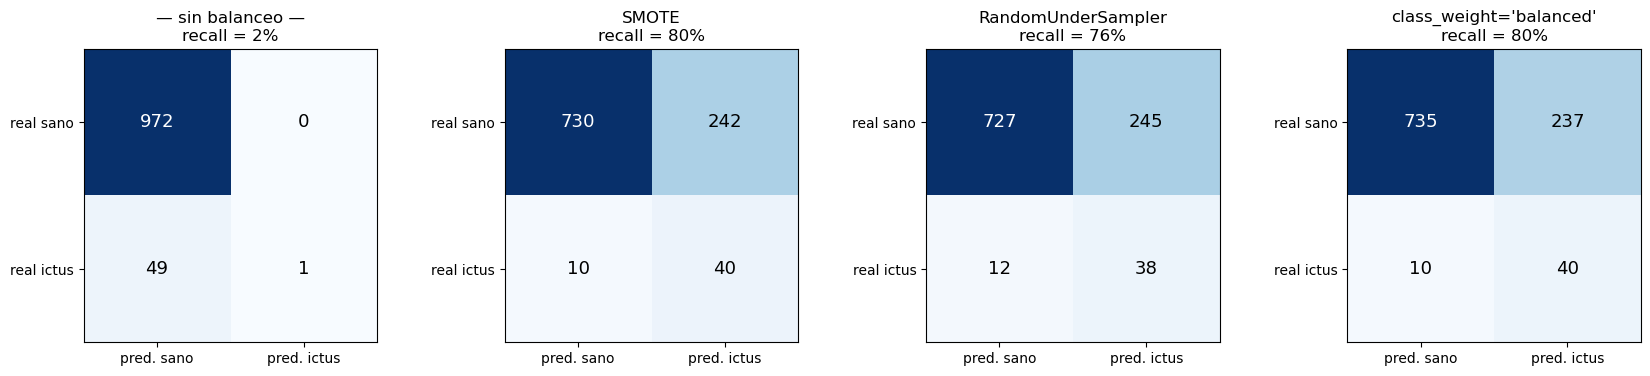

In [27]:
seleccion = ["— sin balanceo —", "SMOTE", "RandomUnderSampler", "class_weight='balanced'"]

fig, axes = plt.subplots(1, len(seleccion), figsize=(17, 3.8))
for ax, nombre in zip(axes, seleccion):
    pred = (probas[nombre] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=13,
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    r = tabla.loc[nombre, "recall"]
    ax.set(xticks=[0, 1], yticks=[0, 1],
           xticklabels=["pred. sano", "pred. ictus"], yticklabels=["real sano", "real ictus"],
           title=f"{nombre}\nrecall = {r:.0%}")
plt.tight_layout()
plt.show()

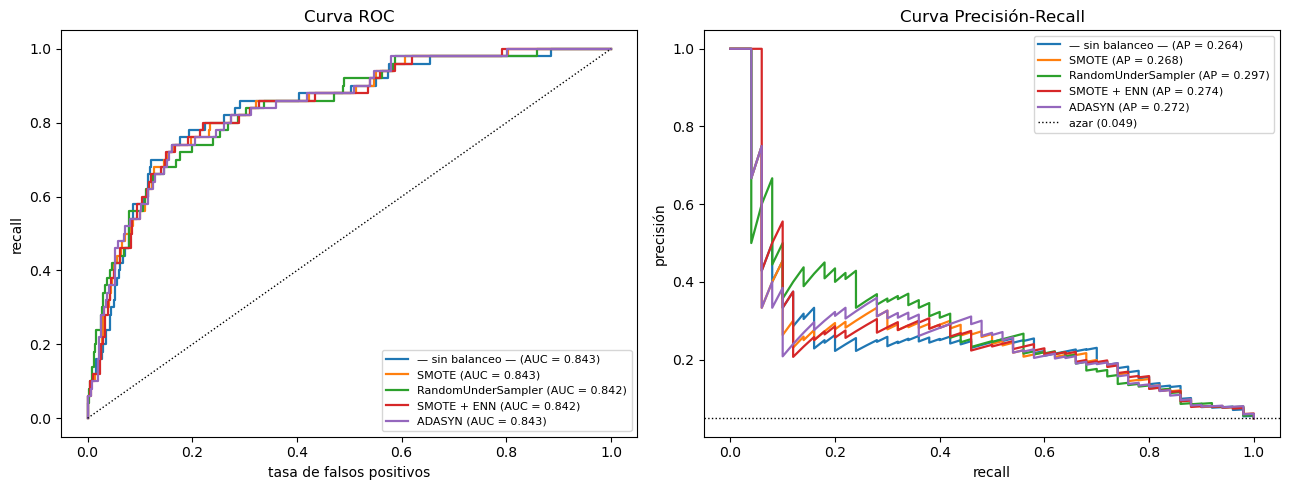

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nombre in ["— sin balanceo —", "SMOTE", "RandomUnderSampler", "SMOTE + ENN", "ADASYN"]:
    fpr, tpr, _ = roc_curve(y_test, probas[nombre])
    axes[0].plot(fpr, tpr, lw=1.6, label=f"{nombre} (AUC = {tabla.loc[nombre,'ROC-AUC']:.3f})")
    pr, rc, _ = precision_recall_curve(y_test, probas[nombre])
    axes[1].plot(rc, pr, lw=1.6, label=f"{nombre} (AP = {tabla.loc[nombre,'PR-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set(xlabel="tasa de falsos positivos", ylabel="recall", title="Curva ROC")
axes[0].legend(fontsize=8, loc="lower right")

axes[1].axhline(y_test.mean(), color="k", ls=":", lw=1, label=f"azar ({y_test.mean():.3f})")
axes[1].set(xlabel="recall", ylabel="precisión", title="Curva Precisión-Recall")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Aquí aparece el resultado más importante de todo el ejercicio: **las curvas están prácticamente
superpuestas**. El ROC-AUC vale ~0,843 con y sin balanceo, y el PR-AUC se mueve entre 0,25 y 0,30.

Es decir: **el remuestreo no mejora la capacidad del modelo para ordenar pacientes por riesgo.**
Lo que hace es desplazar el **umbral de decisión** implícito. Sin balancear, la probabilidad predicha
casi nunca supera 0,5 y el modelo dice "sano" a todo el mundo; al balancear, las probabilidades se
recalibran hacia arriba y el mismo corte de 0,5 empieza a marcar pacientes.

## 6. ¿Balancear o simplemente mover el umbral?

Si la hipótesis anterior es cierta, debería poder reproducir el efecto del balanceo **sin tocar los
datos**, sólo bajando el umbral del modelo original.

In [29]:
proba_base = probas["— sin balanceo —"]

filas = []
for u in [0.50, 0.30, 0.20, 0.15, 0.12, 0.10, 0.08, 0.05, 0.03]:
    pred = (proba_base >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    filas.append({"umbral": u,
                  "recall": recall_score(y_test, pred),
                  "precisión": precision_score(y_test, pred, zero_division=0),
                  "F1": f1_score(y_test, pred),
                  "TP": tp, "FN": fn, "FP": fp})

barrido = pd.DataFrame(filas).set_index("umbral").round(3)
mejor = barrido["F1"].idxmax()
print(barrido.to_string())
print(f"\nMejor F1 ajustando sólo el umbral : {barrido.loc[mejor,'F1']:.3f} (umbral = {mejor})")
print(f"Mejor F1 con remuestreo           : {tabla['F1'].max():.3f} ({tabla['F1'].idxmax()})")

        recall  precisión     F1  TP  FN   FP
umbral                                       
0.50      0.02      1.000  0.039   1  49    0
0.30      0.10      0.357  0.156   5  45    9
0.20      0.24      0.231  0.235  12  38   40
0.15      0.44      0.239  0.310  22  28   70
0.12      0.60      0.217  0.319  30  20  108
0.10      0.70      0.215  0.329  35  15  128
0.08      0.74      0.188  0.300  37  13  160
0.05      0.80      0.143  0.242  40  10  240
0.03      0.86      0.113  0.199  43   7  339

Mejor F1 ajustando sólo el umbral : 0.329 (umbral = 0.1)
Mejor F1 con remuestreo           : 0.248 (RandomOverSampler)


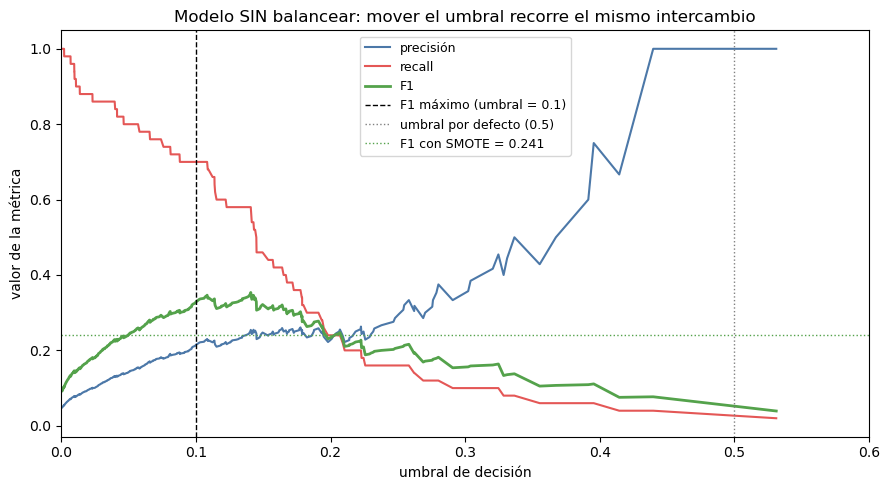

In [30]:
pr, rc, umbrales = precision_recall_curve(y_test, proba_base)
f1_curva = np.divide(2 * pr * rc, pr + rc, out=np.zeros_like(pr), where=(pr + rc) > 0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(umbrales, pr[:-1], label="precisión", color="#4C78A8")
ax.plot(umbrales, rc[:-1], label="recall", color="#E45756")
ax.plot(umbrales, f1_curva[:-1], label="F1", color="#54A24B", lw=2)
ax.axvline(mejor, color="black", ls="--", lw=1, label=f"F1 máximo (umbral = {mejor})")
ax.axvline(0.5, color="gray", ls=":", lw=1, label="umbral por defecto (0.5)")
ax.axhline(tabla.loc["SMOTE", "F1"], color="#54A24B", ls=":", lw=1,
           label=f"F1 con SMOTE = {tabla.loc['SMOTE','F1']:.3f}")
ax.set(xlabel="umbral de decisión", ylabel="valor de la métrica", xlim=(0, 0.6),
       title="Modelo SIN balancear: mover el umbral recorre el mismo intercambio")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Confirmado. Con el modelo **sin balancear** y el umbral en 0,10 se obtiene **F1 = 0,329**, mejor que
cualquier técnica de remuestreo (el mejor fue `RandomOverSampler` con 0,248). El balanceo por
remuestreo es, en este dataset, un **ajuste implícito y poco controlado del umbral**.

Esto no invalida el balanceo —hay clasificadores que sí se benefician de él, y con desbalanceos más
extremos la clase minoritaria puede quedar por debajo del mínimo que el algoritmo necesita para
aprender algo— pero sí obliga a comparar siempre contra la alternativa barata.

### 6.1 Verificación con un clasificador no lineal

La regresión logística podría estar ocultando el efecto. Repetimos con un Random Forest.

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = lambda **kw: RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                         random_state=RANDOM_STATE, n_jobs=-1, **kw)

filas_rf = []
for sampler, nombre in [(None, "— sin balanceo —"),
                        (None, "class_weight='balanced'"),
                        (SMOTE(random_state=RANDOM_STATE), "SMOTE"),
                        (RandomUnderSampler(random_state=RANDOM_STATE), "RandomUnderSampler"),
                        (SMOTETomek(random_state=RANDOM_STATE), "SMOTE + Tomek")]:
    clf = rf(class_weight="balanced") if nombre == "class_weight='balanced'" else rf()
    _, proba, fila = evaluar(sampler, nombre, clf)
    filas_rf.append(fila)

tabla_rf = pd.DataFrame(filas_rf).set_index("estrategia")
print("RANDOM FOREST\n")
print(tabla_rf[["recall", "precisión", "F1", "bal. acc.", "ROC-AUC", "PR-AUC", "TP", "FN", "FP"]]
      .round(3).to_string())

RANDOM FOREST

                         recall  precisión     F1  bal. acc.  ROC-AUC  PR-AUC  TP  FN   FP
estrategia                                                                                
— sin balanceo —           0.00      0.000  0.000      0.500    0.821   0.199   0  50    0
class_weight='balanced'    0.14      0.233  0.175      0.558    0.816   0.185   7  43   23
SMOTE                      0.16      0.200  0.178      0.564    0.802   0.156   8  42   32
RandomUnderSampler         0.84      0.120  0.210      0.762    0.826   0.212  42   8  308
SMOTE + Tomek              0.16      0.205  0.180      0.564    0.797   0.155   8  42   31


El Random Forest **cambia el diagnóstico**, y conviene no esconderlo:

- Sin balancear no detecta **ni un solo ictus** (recall 0 %): peor aún que la regresión logística.
- `SMOTE` y `class_weight` apenas lo mueven (recall 14-16 %). Un bosque profundo memoriza los
  ejemplos sintéticos de SMOTE en lugar de generalizar a partir de ellos, así que el remuestreo
  se diluye.
- Sólo `RandomUnderSampler` lo desbloquea (recall 84 %), al precio de 308 falsas alarmas.
- El ROC-AUC (0,80-0,83) sigue siendo el mismo para todas las variantes, e incluso algo **inferior**
  al de la regresión logística (0,843).

Moraleja: **la técnica de balanceo no se puede elegir en abstracto, depende del clasificador.**
Lo que funciona con un modelo lineal puede ser inútil con un modelo de árboles.

### 6.2 ¿Sirvieron para algo los indicadores de ausencia?

Comprobamos la hipótesis de la sección 2: si la ausencia de `bmi` es informativa, `bmi_missing`
debería tener un peso apreciable en el modelo.

In [32]:
modelo_ref = modelos["class_weight='balanced'"]
coef = pd.Series(modelo_ref.named_steps["clf"].coef_[0], index=NOMBRES)

peso = (coef.abs().sort_values(ascending=False) / coef.abs().sum() * 100).round(2)
ranking_vars = pd.DataFrame({"coeficiente": coef[peso.index].round(3),
                             "% del peso total": peso})
print(ranking_vars.head(12).to_string())

r_flag = list(peso.index).index("bmi_missing") + 1
print(f"\n'bmi_missing' ocupa el puesto {r_flag} de {len(peso)} variables por importancia.")

                                coeficiente  % del peso total
age                                   1.835             22.93
bmi_missing                           1.610             20.12
work_type_children                    0.739              9.24
hypertension                          0.666              8.33
work_type_Self-employed              -0.589              7.36
smoking_status_never smoked          -0.395              4.93
gender_Male                          -0.332              4.15
work_type_Govt_job                   -0.305              3.81
work_type_Private                    -0.291              3.63
heart_disease                         0.250              3.13
avg_glucose_level                     0.176              2.20
smoking_status_formerly smoked       -0.174              2.17

'bmi_missing' ocupa el puesto 2 de 20 variables por importancia.


In [33]:
# Comparación directa: ¿qué se pierde al no incluir los indicadores?
sin_flags = [i for i, n in enumerate(NOMBRES) if n not in VAR_FLAG]

comp = []
for etiqueta, cols in [("con indicadores de ausencia", list(range(len(NOMBRES)))),
                       ("sin indicadores de ausencia", sin_flags)]:
    m = PipelineImb([("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                random_state=RANDOM_STATE))])
    m.fit(X_train_cod[:, cols], y_train)
    p = m.predict(X_test_cod[:, cols])
    s = m.predict_proba(X_test_cod[:, cols])[:, 1]
    comp.append({"variante": etiqueta, "recall": recall_score(y_test, p),
                 "F1": f1_score(y_test, p), "ROC-AUC": roc_auc_score(y_test, s),
                 "PR-AUC": average_precision_score(y_test, s)})

pd.DataFrame(comp).set_index("variante").round(4)

,recall,F1,ROC-AUC,PR-AUC
variante,,,,
con indicadores de ausencia,0.8,0.2446,0.8428,0.2616
sin indicadores de ausencia,0.8,0.2339,0.8428,0.2652


El resultado obliga a matizar la sección 2. `bmi_missing` es la **segunda variable más importante**
del modelo (20 % del peso total de los coeficientes, sólo por detrás de `age`), lo que confirma que
la ausencia era informativa. Pero en el test la ganancia es **marginal**: F1 pasa de 0,234 a 0,245,
el ROC-AUC no se mueve (0,8428 en ambos casos) y el PR-AUC incluso baja una milésima.

La explicación es que `bmi_missing` está fuertemente correlacionada con `age` y con la gravedad del
caso, así que el modelo ya capturaba casi toda esa señal por otras vías. El indicador se queda
—cuesta una columna, no hace daño y documenta explícitamente un sesgo del dataset— pero no hay que
venderlo como el factor decisivo.

> **Advertencia metodológica:** que la ausencia de `bmi` prediga el ictus tan bien es muy probablemente
> un artefacto de cómo se recogieron los datos (a un paciente con ictus grave no se le pesa), no una
> relación causal. En un sistema real desplegado en el momento del ingreso, esa variable **no estaría
> disponible todavía** y el modelo perdería ese 20 % de peso. Es un caso de libro de *fuga temporal*.

## 7. Conclusiones

### Valores faltantes

| | |
|---|---|
| Nulos declarados | `bmi`: 201 (3,9 %) |
| Nulos ocultos | `smoking_status = "Unknown"`: 1 544 (30,2 %) |
| Mecanismo | **No es MCAR** (chi² = 98,6, p ≈ 3e-23): quien no tiene `bmi` registrado tiene **4,7 veces más ictus** |
| Eliminar filas | Descartado: borra 40 de 249 positivos (**16 % de la clase minoritaria**) |
| Método elegido | **MICE** para numéricas (−11,6 % RMSE frente a la media), moda para categóricas |
| Extra | Indicadores `bmi_missing` / `smoking_missing` para conservar la señal de la ausencia |

Lo que hay que llevarse: **antes de imputar, hay que averiguar por qué falta el dato.** Aquí la
ausencia era en sí misma un predictor, y la imputación silenciosa la habría borrado.

### Balanceo

| | |
|---|---|
| Desbalanceo | 4 861 / 249 → **1 : 19,5** (4,87 % positivos) |
| Sin balancear | accuracy 95,2 % pero **recall 2 %**: detecta 1 ictus de 50 |
| Con balanceo | **recall 76-80 %** (38-40 ictus de 50), precisión ~14 % |
| ROC-AUC | **0,843 en todos los casos**: el remuestreo no mejora la ordenación por riesgo |
| Alternativa | Bajar el umbral a 0,10 sin tocar los datos da **F1 = 0,329**, mejor que cualquier remuestreo |

Tres lecciones:

1. **La exactitud miente con clases desbalanceadas.** El 95,2 % del modelo base corresponde a un
   clasificador que no detecta a nadie. Recall, F1, bal. acc. y PR-AUC son las métricas honestas.
2. **El remuestreo es, en gran medida, un ajuste encubierto del umbral.** Las curvas ROC y PR apenas
   se mueven. Antes de sintetizar datos conviene probar `class_weight` o calibrar el umbral: son
   más baratos, reversibles y explícitos.
3. **La mejor técnica depende del clasificador.** Con regresión logística casi todas dan recall 80 %;
   con Random Forest sólo funciona el submuestreo aleatorio (84 %) y SMOTE se queda en el 16 %.
   No existe un ganador universal: hay que medirlo en cada combinación.
4. **El test no se toca nunca.** Ni se imputa con sus estadísticos ni se remuestrea. Debe mantener
   la prevalencia real del 4,87 % para que las métricas describan lo que pasaría en producción.

### Sobre la decisión final

Con recall 80 % y precisión 14 %, el modelo genera ~240 falsas alarmas para capturar 40 ictus. Si
esto fuera un **cribado** cuyo coste es una consulta de seguimiento, es un intercambio razonable:
un ictus no detectado cuesta muchísimo más que una consulta de más. El umbral no es una decisión
estadística, es una decisión clínica; lo que el análisis aporta es la **curva completa** de opciones
para que alguien pueda elegir con criterio.